In [2]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

import tensorflow as tf
from tensorflow.keras import layers, models

In [3]:
# Cell 2: Dataset paths

DATASET_PATH = "C:/Users/agamb/Desktop/Data"  

TRAIN_DIR = DATASET_PATH + "/train"
VAL_DIR = DATASET_PATH + "/val"

IMG_SIZE = (224, 224)
BATCH_SIZE = 16

In [4]:
# Cell 3: Load data in batches

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)

class_names = train_ds.class_names
print("Classes:", class_names)

Found 3691 files belonging to 2 classes.
Found 368 files belonging to 2 classes.
Classes: ['Control', 'Loose']


In [5]:
AUTOTUNE = tf.data.AUTOTUNE

normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [6]:
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

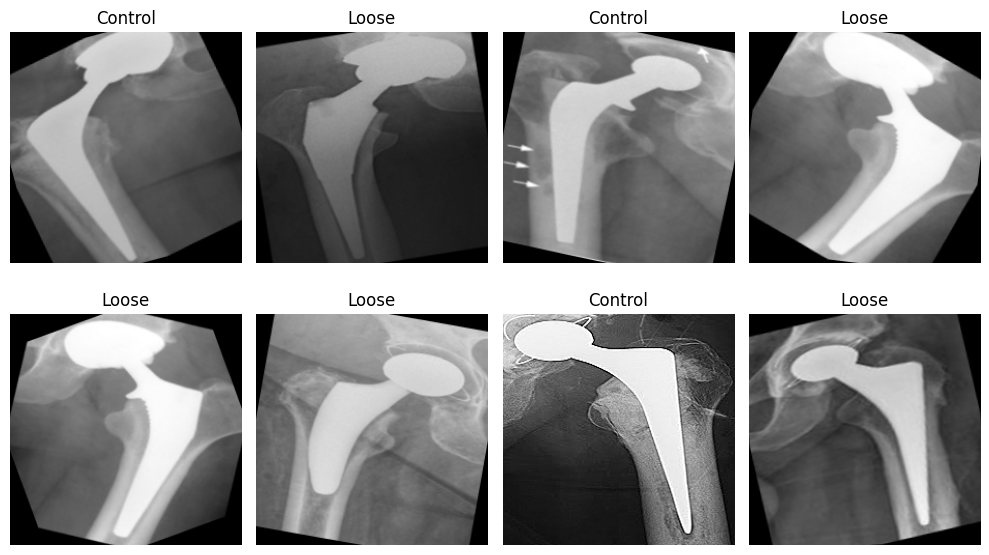

In [7]:
# Cell 5: Show sample images

plt.figure(figsize=(10, 6))

for images, labels in train_ds.take(1):
    for i in range(8):
        plt.subplot(2, 4, i + 1)
        plt.imshow(images[i])
        plt.title(class_names[int(labels[i][0])])
        plt.axis("off")

plt.tight_layout()
plt.show()

Train counts: {'Control': 1798, 'Loose': 1894}
Validation counts: {'Control': 176, 'Loose': 192}


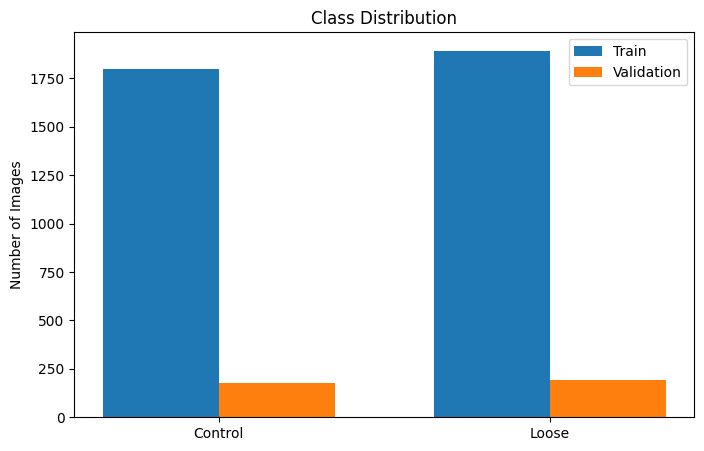

In [8]:
train_counts = {}
val_counts = {}

for class_name in class_names:
    train_counts[class_name] = len(list((tf.io.gfile.glob(TRAIN_DIR + "/" + class_name + "/*"))))
    val_counts[class_name] = len(list((tf.io.gfile.glob(VAL_DIR + "/" + class_name + "/*"))))

print("Train counts:", train_counts)
print("Validation counts:", val_counts)

plt.figure(figsize=(8, 5))
x = np.arange(len(class_names))
width = 0.35

plt.bar(x - width/2, train_counts.values(), width, label="Train")
plt.bar(x + width/2, val_counts.values(), width, label="Validation")

plt.xticks(x, class_names)
plt.ylabel("Number of Images")
plt.title("Class Distribution")
plt.legend()
plt.show()

In [10]:
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score

DATASET_PATH = r"C:\Users\agamb\Desktop\Data"  # change only if needed

TRAIN_DIR = os.path.join(DATASET_PATH, "train")
VAL_DIR = os.path.join(DATASET_PATH, "val")

IMG_SIZE = (128, 128)   # use 128 first to avoid memory crash
BATCH_SIZE = 8          # small batch for your system

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)

class_names = train_ds.class_names
print("Classes:", class_names)

normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

Found 3691 files belonging to 2 classes.
Found 368 files belonging to 2 classes.
Classes: ['Control', 'Loose']


In [11]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(128, 128, 3)),

    tf.keras.layers.Conv2D(16, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(32, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,809 (108.63 KB)

 Trainable params: 27,809 (108.63 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10


462/462 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.5077 - loss: 0.6939 - val_accuracy: 0.3451 - val_loss: 0.6969
Epoch 2/10
462/462 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.5465 - loss: 0.6884 - val_accuracy: 0.4511 - val_loss: 0.7303
Epoch 3/10
462/462 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.5801 - loss: 0.6830 - val_accuracy: 0.3261 - val_loss: 0.7317
Epoch 4/10
462/462 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.6042 - loss: 0.6718 - val_accuracy: 0.3125 - val_loss: 0.7436
Epoch 5/10
462/462 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.6080 - loss: 0.6637 - val_accuracy: 0.3777 - val_loss: 0.7540
Epoch 6/10
462/462 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.6223 - loss: 0.6564 - val_accuracy: 0.3641 - val_loss: 0.7908
Epoch 7/10
462/462 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.6410 - loss: 0.6247 - val_accuracy: 0.3967 - val_loss: 0.7953
Epoch 8/10
462/462 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.6822 - loss: 0.5898 - val_accuracy: 0.388

Accuracy: 0.3804347826086957
Precision: 0.375
Recall: 0.28125
F1 Score: 0.32142857142857145
              precision    recall  f1-score   support

     Control       0.38      0.49      0.43       176
       Loose       0.38      0.28      0.32       192

    accuracy                           0.38       368
   macro avg       0.38      0.38      0.38       368
weighted avg       0.38      0.38      0.37       368



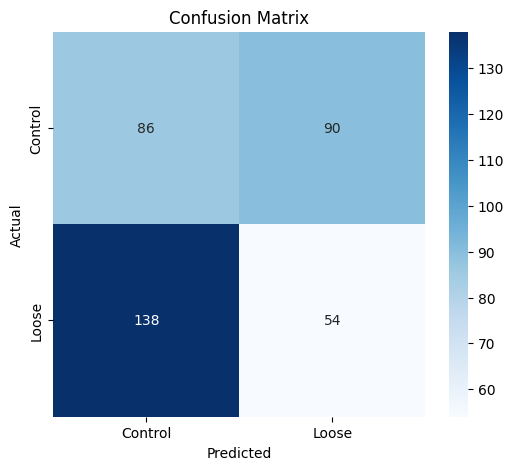

In [13]:
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    preds = (preds > 0.5).astype("int32")

    y_true.extend(labels.numpy().astype("int32").flatten())
    y_pred.extend(preds.flatten())

print("Accuracy:", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred))
print("Recall:", recall_score(y_true, y_pred))
print("F1 Score:", f1_score(y_true, y_pred))

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [14]:
# Cell 2: Imports

from ultralytics import YOLO
import os
from IPython.display import Image, display

Creating new Ultralytics Settings v0.0.6 file  
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\agamb\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [15]:
model = YOLO("yolov8s-cls.pt")   # stronger than yolov8n-cls.pt

results = model.train(
    data=DATASET_PATH,
    epochs=100,
    imgsz=224,
    batch=8,
    patience=20,
    optimizer="AdamW",
    lr0=0.0005,
    weight_decay=0.0005,
    dropout=0.2,
    name="bone_control_loose_yolov8s_cls",
    plots=True
)

Ultralytics 8.4.54  Python-3.10.6 torch-2.12.0+cpu CPU (12th Gen Intel Core i5-12500H)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\agamb\Desktop\Data, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.2, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=bone_control_loose_yolov8s_cls, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW,

In [1]:
from ultralytics import YOLO

DATASET_PATH = r"C:\Users\agamb\Desktop\Data"

model = YOLO("yolov8s-cls.pt")

results = model.train(
    data=DATASET_PATH,
    epochs=50,
    imgsz=224,
    batch=4,
    project=r"C:\Users\agamb\Desktop\YOLO_Results",
    name="bone_control_loose",
    exist_ok=True,
    plots=True,
    save=True
)

New https://pypi.org/project/ultralytics/8.4.55 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.54  Python-3.10.6 torch-2.12.0+cpu CPU (12th Gen Intel Core i5-12500H)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\agamb\Desktop\Data, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name

In [2]:
from pathlib import Path

weights_dir = Path(r"C:\Users\agamb\Desktop\YOLO_Results\bone_control_loose\weights")

print("Files in weights folder:")
for f in weights_dir.glob("*"):
    print(f)

Files in weights folder:
C:\Users\agamb\Desktop\YOLO_Results\bone_control_loose\weights\best.pt
C:\Users\agamb\Desktop\YOLO_Results\bone_control_loose\weights\last.pt


In [3]:
from ultralytics import YOLO

model = YOLO(r"C:\Users\agamb\Desktop\YOLO_Results\bone_control_loose\weights\best.pt")

In [4]:
metrics = model.val(data=DATASET_PATH)
print(metrics)

Ultralytics 8.4.54  Python-3.10.6 torch-2.12.0+cpu CPU (12th Gen Intel Core i5-12500H)
YOLOv8s-cls summary (fused): 30 layers, 5,077,762 parameters, 0 gradients, 12.4 GFLOPs
train: C:\Users\agamb\Desktop\Data\train... found 3691 images in 2 classes  
val: C:\Users\agamb\Desktop\Data\val... found 368 images in 2 classes  
test: None...
val: Fast image access  (ping: 0.20.2 ms, read: 55.323.4 MB/s, size: 49.2 KB)
val: Scanning C:\Users\agamb\Desktop\Data\val... 368 images, 0 corrupt: 100% ━━━━━━━━━━━━ 368/368  0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 23/23 5.1it/s 4.5s0.2s
                   all      0.943          1
Speed: 0.0ms preprocess, 9.5ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to C:\Users\agamb\runs\classify\val
ultralytics.utils.metrics.ClassifyMetrics object with attributes:

confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x000001AF72336C50>
curves: []
curves_results: []
fitness: 0.9714674055576324
k

In [5]:
from IPython.display import Image, display
from pathlib import Path

SAVE_DIR = Path(r"C:/Users/agamb/runs/classify/val")

for file in SAVE_DIR.iterdir():
    print(file)

C:\Users\agamb\runs\classify\val\confusion_matrix.png
C:\Users\agamb\runs\classify\val\confusion_matrix_normalized.png
C:\Users\agamb\runs\classify\val\val_batch0_labels.jpg
C:\Users\agamb\runs\classify\val\val_batch0_pred.jpg
C:\Users\agamb\runs\classify\val\val_batch1_labels.jpg
C:\Users\agamb\runs\classify\val\val_batch1_pred.jpg
C:\Users\agamb\runs\classify\val\val_batch2_labels.jpg
C:\Users\agamb\runs\classify\val\val_batch2_pred.jpg


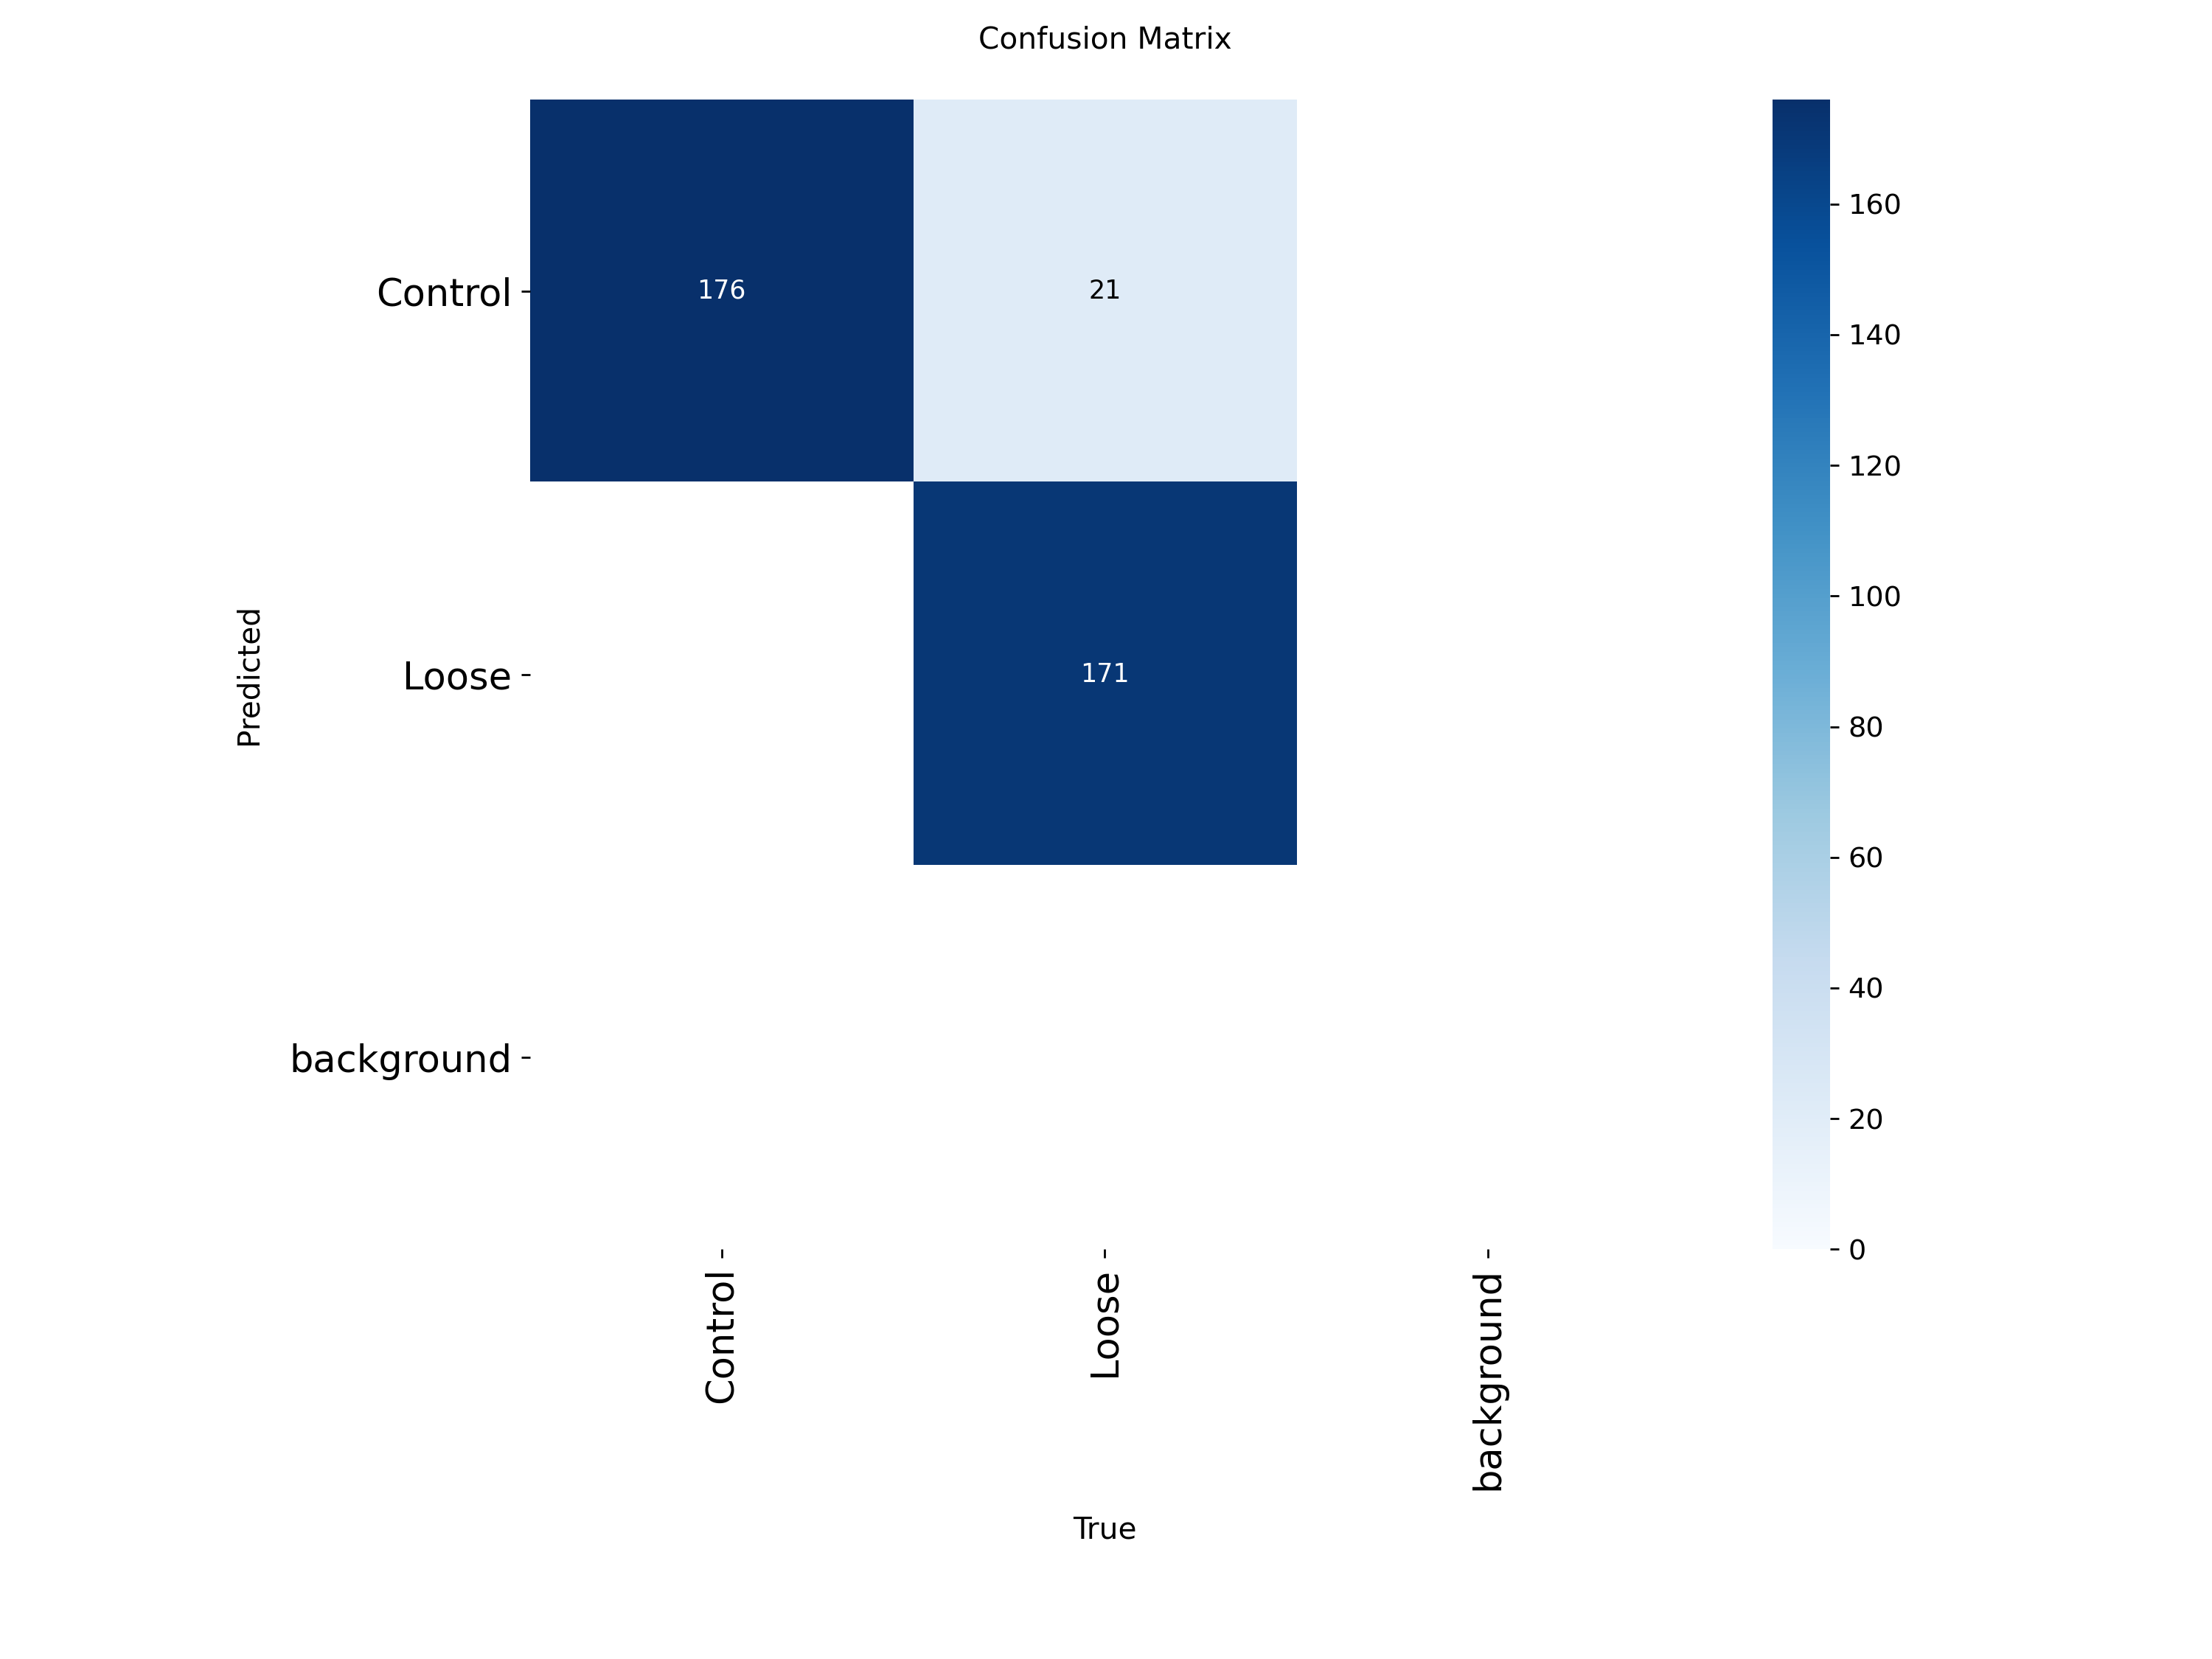

In [6]:
display(Image(filename=str(SAVE_DIR / "confusion_matrix.png")))

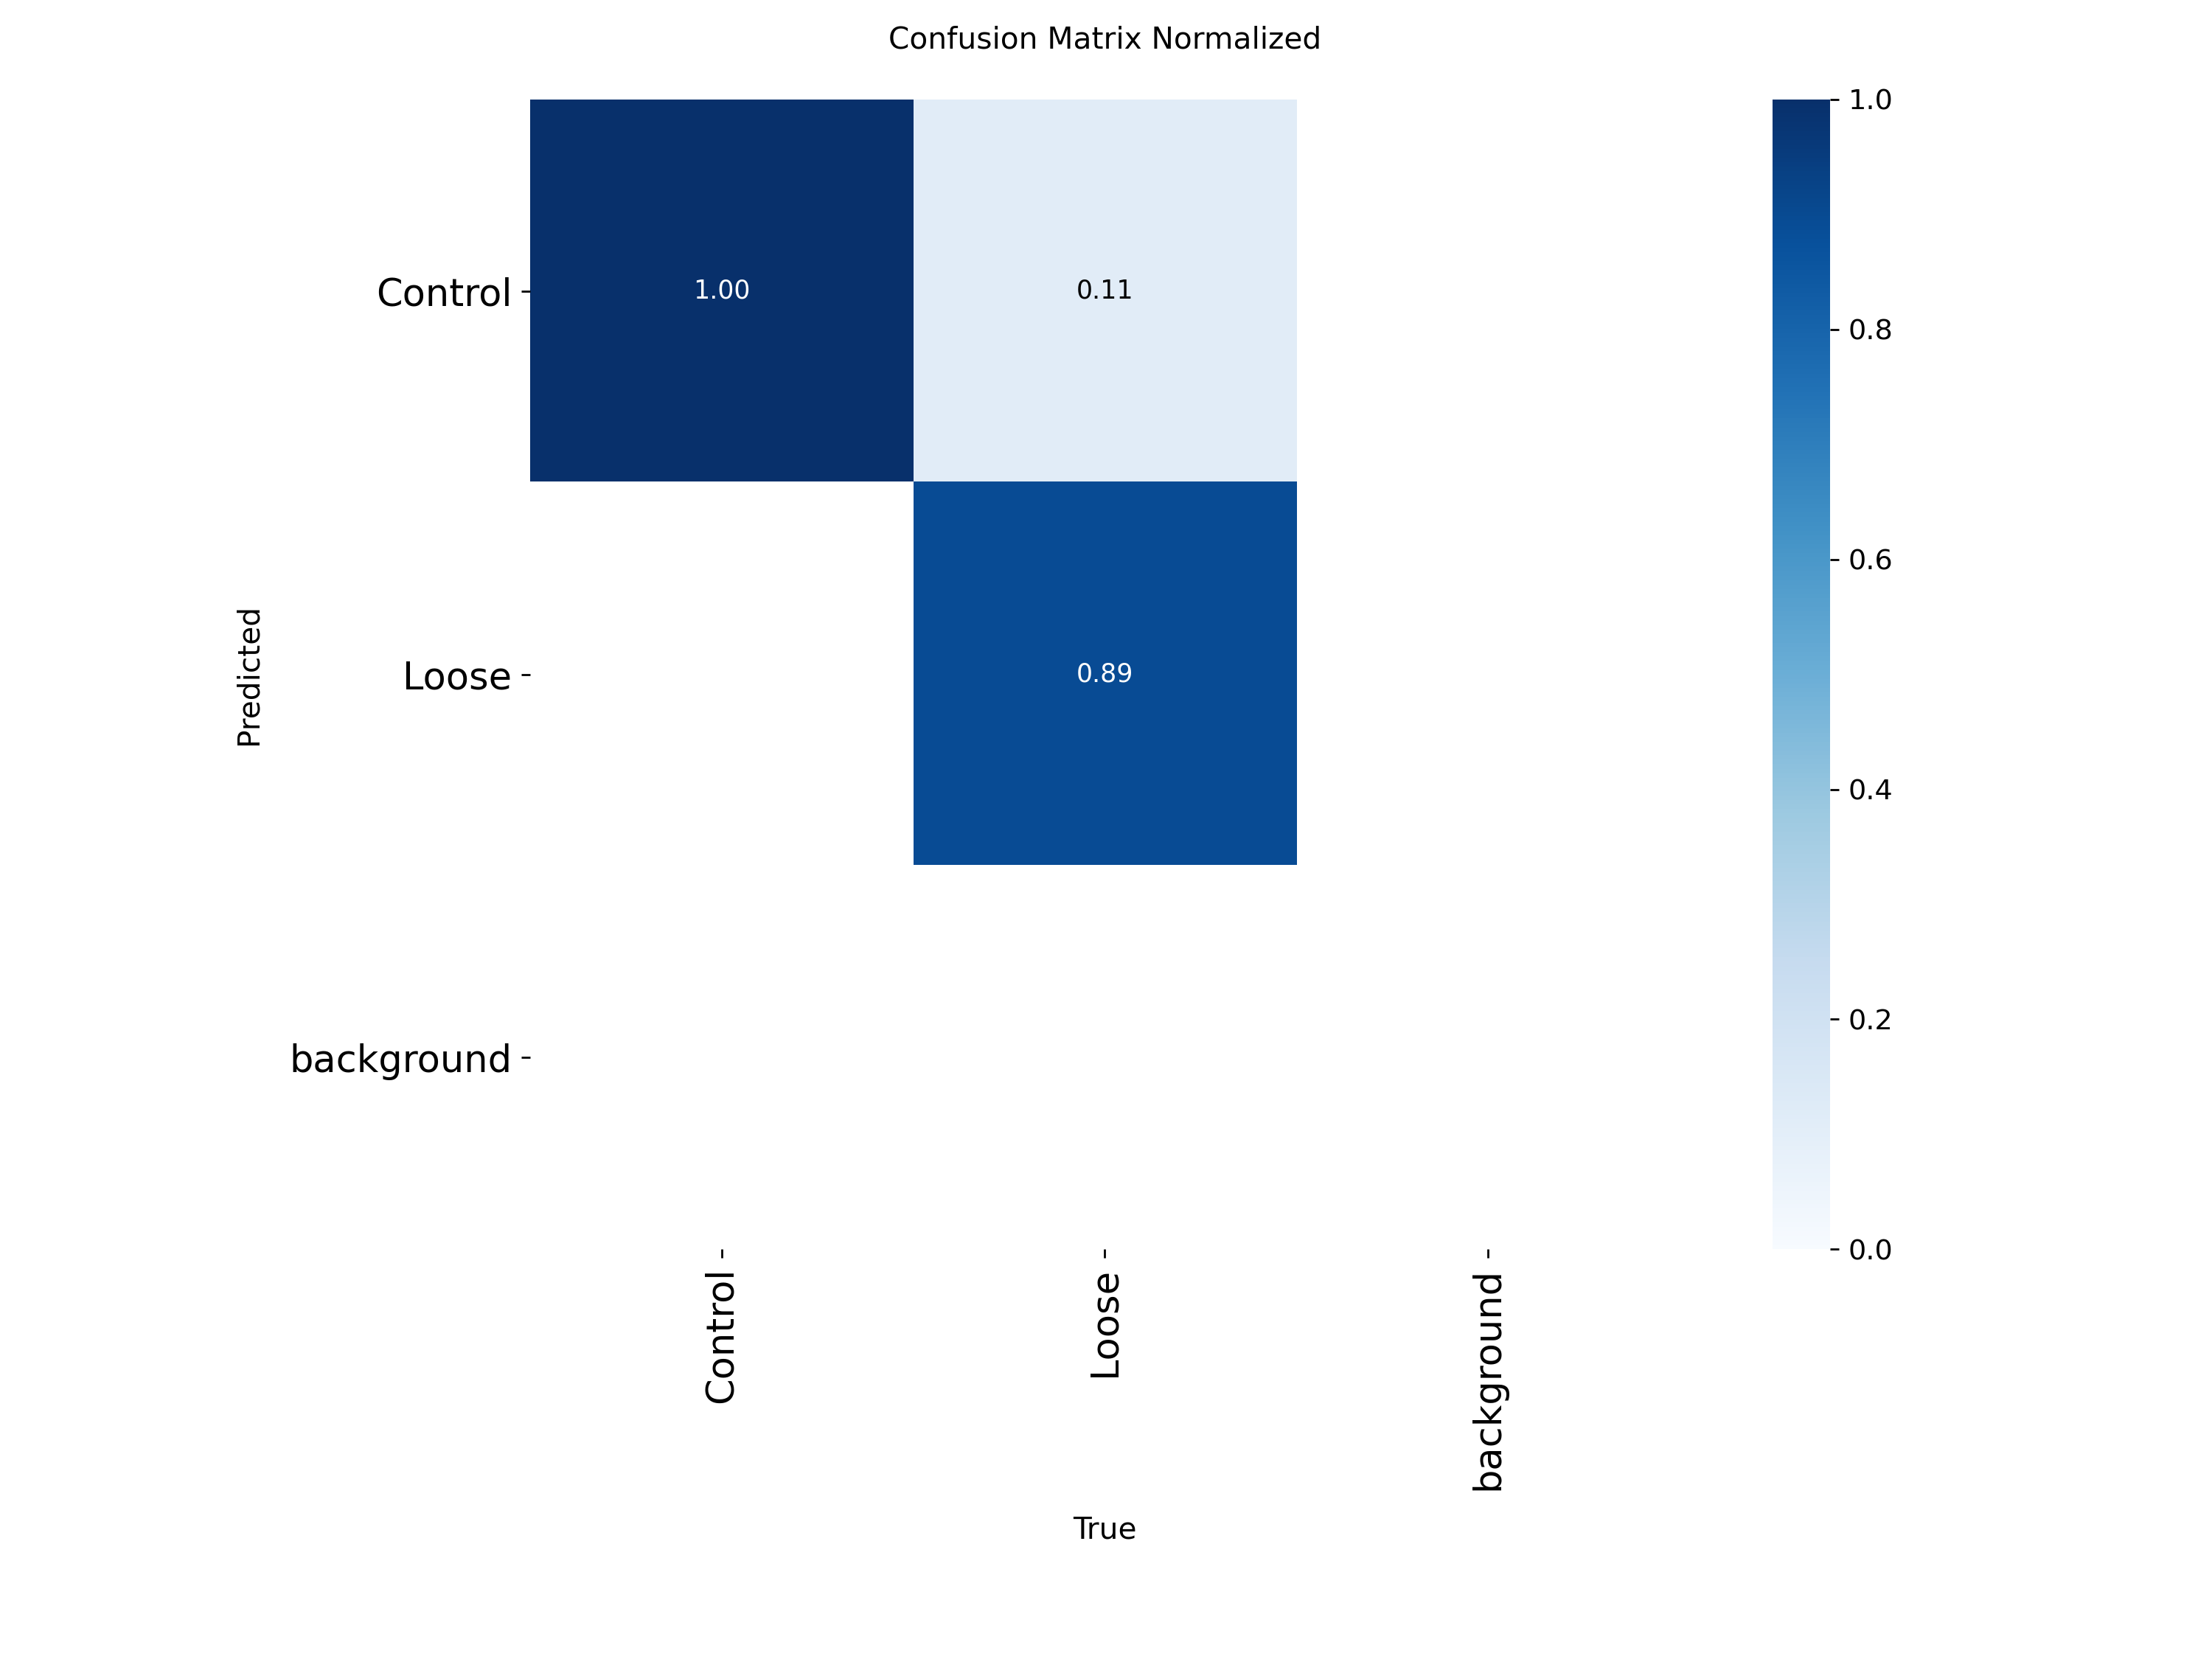

In [7]:
display(Image(filename=str(SAVE_DIR / "confusion_matrix_normalized.png")))

In [8]:
from pathlib import Path

for file in Path(r"C:/Users/agamb/runs/classify").rglob("results.png"):
    print(file)

C:\Users\agamb\runs\classify\bone_control_loose_yolov8s_cls\results.png


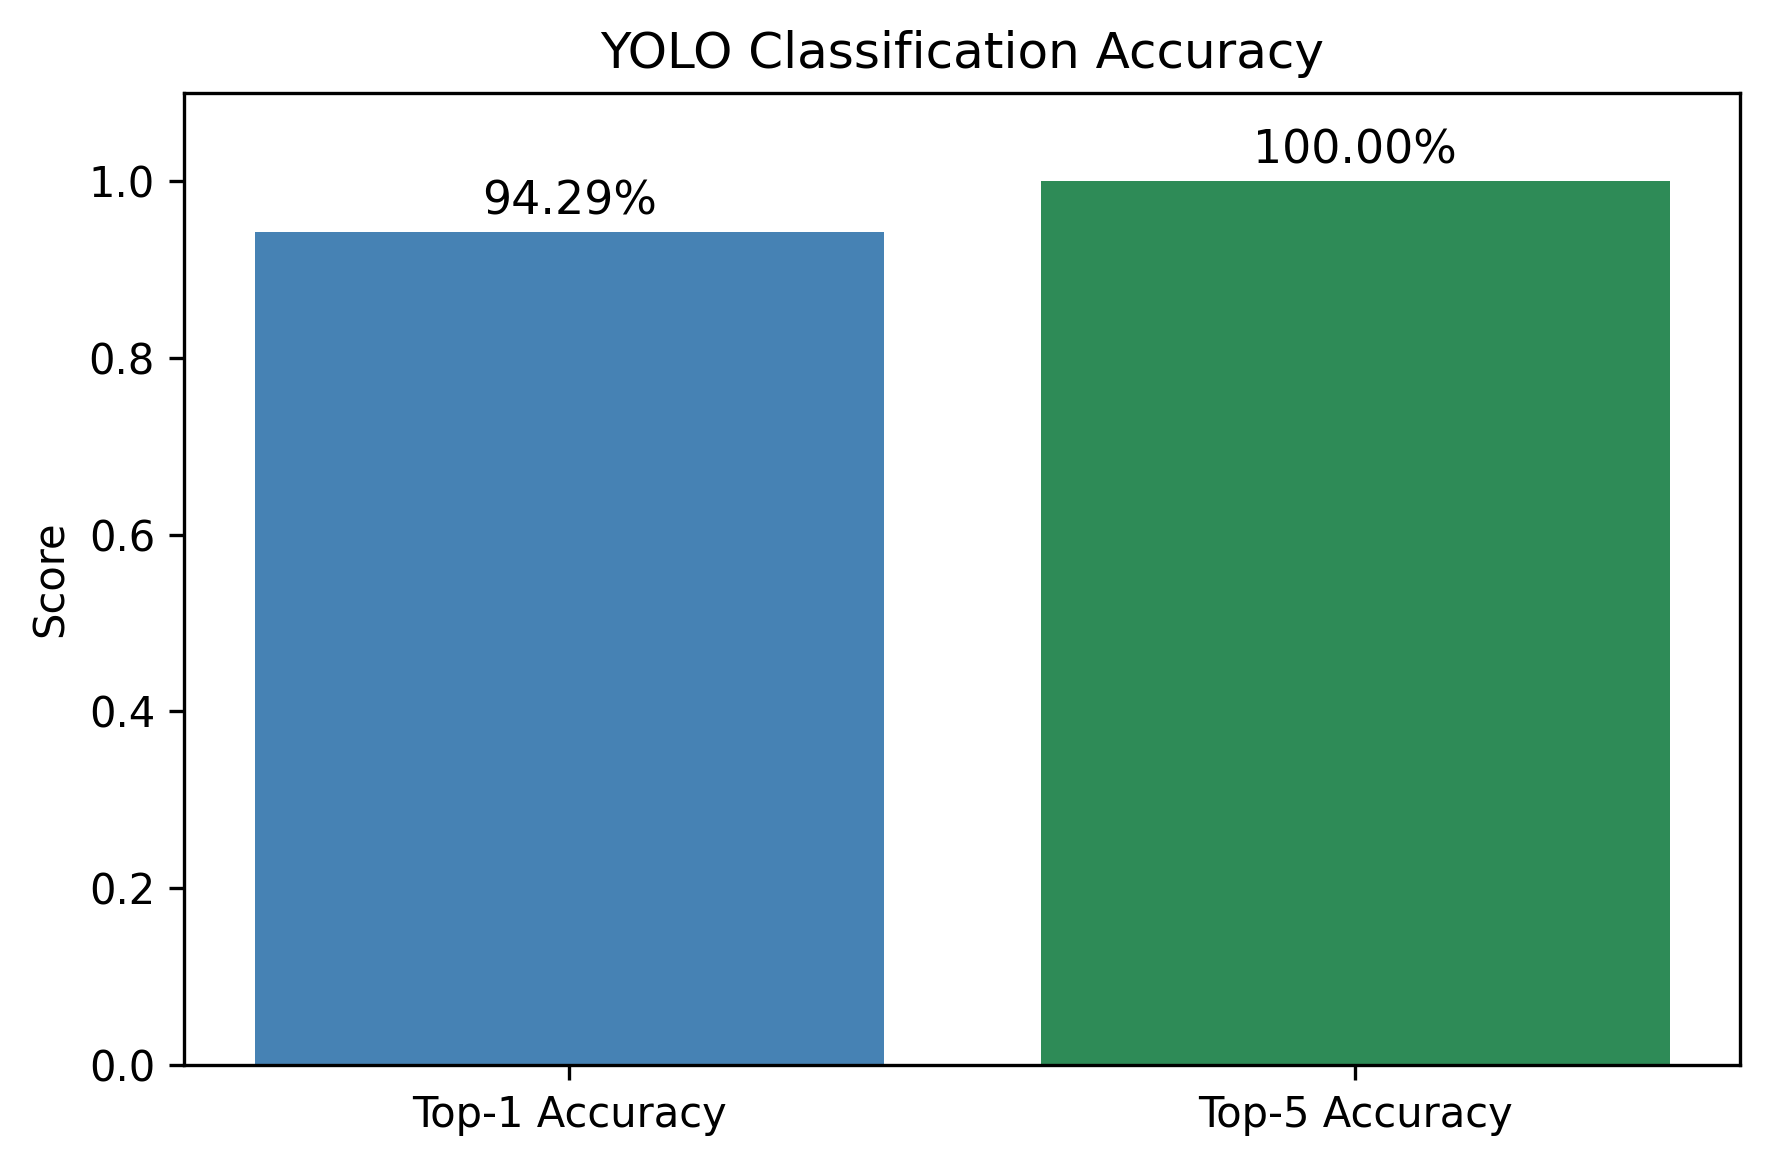

In [19]:
import matplotlib.pyplot as plt
from IPython.display import Image, display
from pathlib import Path

accuracy = 0.9429348111152649
top5 = 1.0

save_path = Path("yolo_accuracy_graph.png")

fig, ax = plt.subplots(figsize=(6, 4))

bars = ax.bar(
    ["Top-1 Accuracy", "Top-5 Accuracy"],
    [accuracy, top5],
    color=["steelblue", "seagreen"]
)

ax.set_ylim(0, 1.1)
ax.set_ylabel("Score")
ax.set_title("YOLO Classification Accuracy")

for bar, value in zip(bars, [accuracy, top5]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.02,
        f"{value * 100:.2f}%",
        ha="center",
        fontsize=11
    )

fig.tight_layout()
fig.savefig(save_path, dpi=300, bbox_inches="tight")
plt.close(fig)

display(Image(filename=str(save_path)))

In [20]:
from pathlib import Path

pt_files = list(Path(r"C:/Users/agamb/runs/classify").rglob("*.pt"))

print("All saved YOLO weight files:")
for f in pt_files:
    print(f)

All saved YOLO weight files:
C:\Users\agamb\runs\classify\bone_control_loose_yolov8s_cls\weights\best.pt
C:\Users\agamb\runs\classify\bone_control_loose_yolov8s_cls\weights\last.pt
